In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Breast Cancer Dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset loaded successfully!")
print("Dataset shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

Dataset loaded successfully!
Dataset shape: (569, 30)
Target shape: (569,)

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


In [3]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [4]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training data shape: (455, 30)
Scaled testing data shape: (114, 30)


In [5]:
# Train Logistic Regression Model

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [6]:
# Make Predictions

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculate Performance Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("===== MODEL PERFORMANCE =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")

===== MODEL PERFORMANCE =====
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861


Confusion Matrix:
[[41  1]
 [ 1 71]]


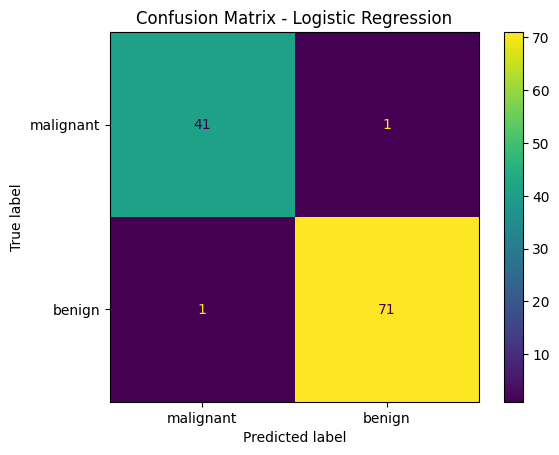

In [7]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

ROC-AUC Score: 0.9954


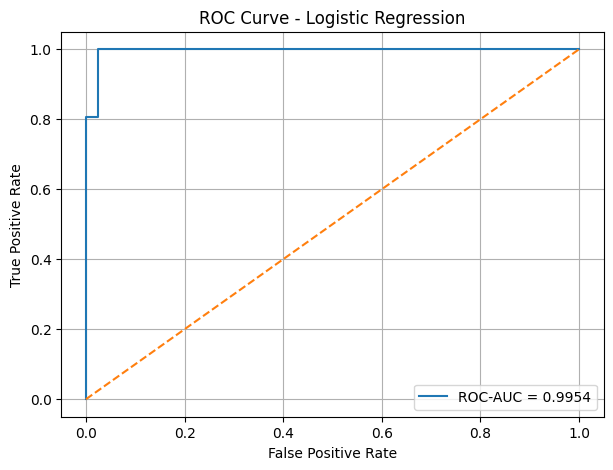

In [8]:
# ROC-AUC Score and ROC Curve

roc_auc = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()
plt.show()

In [9]:
# Threshold Tuning

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

print("===== THRESHOLD TUNING =====")

for threshold in thresholds_to_test:
    y_threshold = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_test, y_threshold)
    prec = precision_score(y_test, y_threshold, zero_division=0)
    rec = recall_score(y_test, y_threshold, zero_division=0)

    print(
        f"Threshold = {threshold} | "
        f"Accuracy = {acc:.4f} | "
        f"Precision = {prec:.4f} | "
        f"Recall = {rec:.4f}"
    )

===== THRESHOLD TUNING =====
Threshold = 0.3 | Accuracy = 0.9825 | Precision = 0.9730 | Recall = 1.0000
Threshold = 0.4 | Accuracy = 0.9825 | Precision = 0.9861 | Recall = 0.9861
Threshold = 0.5 | Accuracy = 0.9825 | Precision = 0.9861 | Recall = 0.9861
Threshold = 0.6 | Accuracy = 0.9561 | Precision = 0.9855 | Recall = 0.9444
Threshold = 0.7 | Accuracy = 0.9474 | Precision = 0.9853 | Recall = 0.9306


In [10]:
# Final Classification Report

print("===== FINAL CLASSIFICATION REPORT =====")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

===== FINAL CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

